# **# Major Data Analytics Project**

## Domain
Agriculture

## Project Theme
Seasonal Agriculture Performance Analysis

## Tools Used
Python, Pandas, NumPy, Matplotlib, Seaborn

## Project Goal

The goal of this project is to investigate how agricultural performance varies across different seasons and identify meaningful patterns, trends, relationships, and differences in the available data.

# **Problem Statement**

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability, and market conditions. As a result, agricultural performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed under different seasonal conditions.

The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships, and variations within the available data.

## **Project Objectives**

1. Explore and understand the agricultural dataset.
2. Clean and prepare the data for analysis.
3. Examine agricultural performance across different seasons.
4. Identify important seasonal patterns and trends.
5. Investigate relationships between environmental conditions and agricultural performance.
6. Compare relevant groups across different seasons.
7. Identify significant differences and unusual patterns.
8. Apply suitable statistical and visualization techniques.
9. Develop meaningful insights and evidence-based recommendations.

# **Dataset**

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

**Dataset file:** seasonal_agriculture_performance_dataset.csv

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

The dataset is loaded into a Pandas DataFrame so that it can be explored and analyzed.

In [3]:
# Load the dataset

file_path = "/content/seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


The first five records are displayed to understand the structure and type of information present in the dataset.

In [4]:
# Top 5 rows

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [5]:
# Bottom 5 rows

df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [6]:
# Random sample of records

df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.70,26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [7]:
# Column names

print(df.columns.tolist())


['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [9]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [58]:
# Dataset Shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 4000
Number of columns: 28
Dataset shape: (4000, 28)


In [59]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [10]:
# Numerical summary statistics

df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,3952.00,4000.00,4000.00,4000.00,4000.00,3960.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,3968.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


In [12]:
#categorical columns
df.describe(include='object')

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


# **Data Quality Analysis**

Description:
Before performing the analysis, we investigate missing values, duplicate records, data types, and unusual values. This helps us understand the quality of the dataset and decide whether any cleaning is required.

**Missing Values identified and handling**

---



In [13]:
# Missing values

missing = df.isnull().sum().sort_values(ascending=False)

missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage.round(2)
})

missing_summary[missing_summary["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


. The missing value analysis identifies the columns containing missing records and shows their corresponding missing percentages. Columns with missing values should be investigated before performing further analysis.

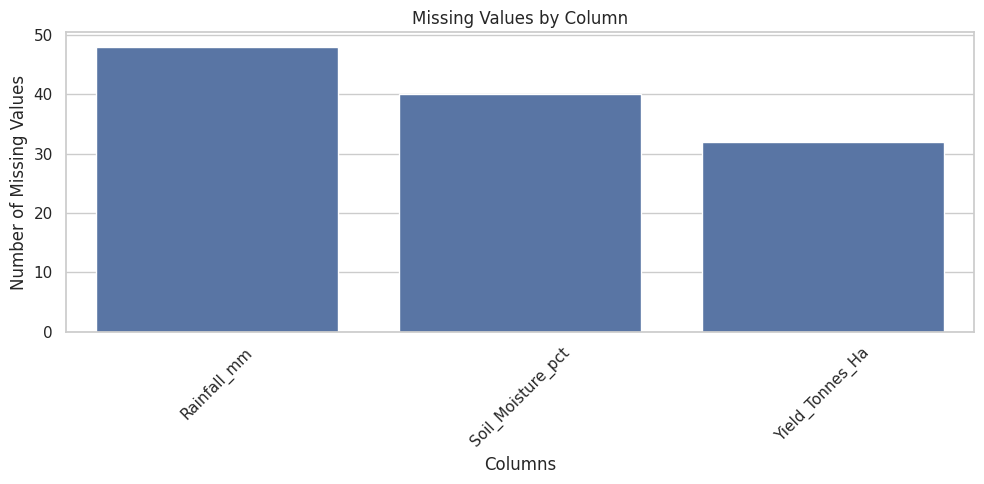

In [14]:
# Visualize missing values

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_values.index,
    y=missing_values.values
)

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

. The bar chart shows the number of missing values present in each column. Only columns containing missing values are displayed. This visualization helps identify which variables require attention during the data-cleaning process.

In [53]:
# Handle missing values

df["Rainfall_mm"] = df["Rainfall_mm"].fillna(df["Rainfall_mm"].median())

df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(
    df["Soil_Moisture_pct"].median()
)

df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(
    df["Yield_Tonnes_Ha"].median()
)

print("Missing values handled successfully!")

df.isnull().sum()

Missing values handled successfully!


,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


Missing values were identified in the dataset and handled using median imputation for the affected numerical variables. The median was selected because it is less affected by extreme values. After treatment, the dataset was checked again to verify that the missing values were handled.

In [18]:
# Check unusual values

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.00,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,3952.00,601.15,288.93,80.00,370.20,582.00,834.95,1395.20
Avg_Temperature_C,4000.00,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.00,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,4000.00,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.00,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,3960.00,26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,4000.00,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.00,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.00,104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [11]:
# Check unique values for categorical columns

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(), "unique values")
    print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


. Check Unique Values:
This code identifies the categorical columns in the dataset and displays the number of unique values and some example values in each column. It helps us understand the different categories present in the dataset.

In [19]:
# Check missing values after duplicate removal

missing_after_duplicates = df.isnull().sum()

missing_after_duplicates = missing_after_duplicates[
    missing_after_duplicates > 0
].sort_values(ascending=False)

missing_after_duplicates

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


. After removing duplicate records, missing values are checked again to ensure that the dataset is ready for further analysis. The number and percentage of missing values in each column are displayed.

**Missing Value Treatment:**

After identifying the missing values, an appropriate treatment method is applied to handle them. Missing values can affect statistical calculations, visualizations, and the accuracy of the analysis. Therefore, they should be handled before performing further analysis.

In this dataset, missing values in numerical columns are treated using the median value of the respective column. The median is selected because it is less affected by extreme values or outliers compared with the mean.

For categorical columns, missing values can be replaced with the mode, which represents the most frequently occurring category.

This approach allows us to retain the available records instead of unnecessarily deleting rows and helps maintain the overall size of the dataset.

After treatment, the dataset is checked again to confirm that the missing values have been handled successfully.

In [21]:
# Missing Value Treatment

# Numerical columns - fill missing values with median
numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())


# Categorical columns - fill missing values with mode
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])


print("Missing values treatment completed.")

Missing values treatment completed.


. Missing values were treated using median imputation for numerical variables and mode imputation for categorical variables. The dataset was then rechecked, confirming that the missing values were successfully handled.

In [22]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct   

**Duplicate records identified and handled**

In [ ]:
# Duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [ ]:
# Remove duplicate records

df = df.drop_duplicates()

print("Duplicate records handled successfully!")
print("Dataset shape after removing duplicates:", df.shape)

Duplicate records handled successfully!
Dataset shape after removing duplicates: (4000, 28)


Duplicate records were identified using the duplicated() function. Any duplicate rows were removed from the dataset to avoid repeated observations affecting the analysis

Feature / Variable Review
Objective.

We review the variables and group them into different categories to understand which variables are most relevant to seasonal agricultural performance and why.

1.Variable Categories

2.Identifier variables

3.Categorical variables

4.Numerical variables

5.Environmental variables

6.Operational variables

7.Production/Performance variables

8.Economic variables

In [24]:
# Numerical and categorical columns

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


. Numerical and Categorical Columns:
The dataset is divided into numerical and categorical variables. Numerical variables contain measurable values such as rainfall, temperature, yield and profit. Categorical variables contain groups or labels such as state, crop, season and irrigation method

### **Descriptive analysis performed**

**Statistical Analysis** – Descriptive Statistics

The next step is to calculate descriptive statistics to understand the central tendency and variation of the numerical variables. Instead of only displaying the statistics, we interpret what they tell us about the agricultural data.

In [66]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,600.92,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.24,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,287.19,3.82,11.96,1.12,0.64,6.68,31.22,17.02,27.74,60.26,1.98,0.10,13.31,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,371.58,23.90,54.77,6.60,6.26,21.80,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,831.98,29.60,71.90,8.10,7.14,31.20,141.22,69.40,123.60,227.20,6.40,0.91,2.83,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


In [25]:
# Descriptive statistics with important measures

descriptive_stats = df.describe().T

descriptive_stats

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.00,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,4000.00,600.92,287.19,80.00,371.58,582.00,831.98,1395.20
Avg_Temperature_C,4000.00,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.00,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,4000.00,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.00,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,4000.00,26.51,6.68,8.00,21.80,26.40,31.20,47.00
Nitrogen_kg_ha,4000.00,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.00,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.00,104.76,27.74,30.00,86.20,105.10,123.60,200.00


**Descriptive statistics** are used to understand the basic characteristics and variation of the numerical variables in the dataset. Count shows the number of available observations, Mean shows the average, Median shows the middle value, Standard Deviation shows the spread of the data, and Minimum and Maximum show the range. The 25%, 50%, and 75% quartiles help understand how the data is distributed. These statistics help identify variables with high variation and possible extreme values before further analysis.

In [26]:
# Descriptive Statistics

descriptive_stats = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Standard_Deviation": df[numeric_columns].std(),
    "Minimum": df[numeric_columns].min(),
    "Maximum": df[numeric_columns].max(),
    "25%": df[numeric_columns].quantile(0.25),
    "50%": df[numeric_columns].quantile(0.50),
    "75%": df[numeric_columns].quantile(0.75)
})

descriptive_stats

,Mean,Median,Standard_Deviation,Minimum,Maximum,25%,50%,75%
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00,4.26,7.89,11.65
Rainfall_mm,600.92,582.00,287.19,80.00,1395.20,371.58,582.00,831.98
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70,23.90,26.90,29.60
Humidity_pct,63.21,63.00,11.96,25.00,95.00,54.77,63.00,71.90
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00,6.60,7.30,8.10
Soil_pH,6.70,6.69,0.64,5.20,8.40,6.26,6.69,7.14
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00,21.80,26.40,31.20
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00,98.50,120.10,141.22
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00,46.20,57.50,69.40
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00,86.20,105.10,123.60


In [27]:
# Seasonal Descriptive Summary

seasonal_summary = df.groupby("Season")[numeric_columns].agg(
    ["mean", "median", "std", "min", "max"]
)

seasonal_summary

Farm_Area_Hectares                        Rainfall_mm                \
                     mean median  std  min   max        mean median    std   
Season                                                                       
Kharif               7.94   8.18 4.28 0.50 15.00      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18 0.50 15.00      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16 0.50 14.99      304.65 288.20 157.24   

                      Avg_Temperature_C                         Humidity_pct  \
          min     max              mean median  std   min   max         mean   
Season                                                                         
Kharif 160.50 1395.20             28.45  28.50 2.51 19.40 36.80        71.81   
Rabi    80.00 1146.50             23.49  23.50 2.46 16.20 31.10        57.89   
Zaid    80.00  708.30             31.04  31.00 2.55 24.50 39.70        52.01   

                               Sunlight_Hours_Day                         \
       median  std   min   max               mean median  std  min   max   
Season                                                                     
Kharif  71.90 8.86 36.90 95.00               6.79   6.80 0.98 3.50 10.30   
Rabi    58.10 9.00 25.00 86.30               7.59   7.60 1.00 4.10 11.00   
Zaid    52.35 9.05 25.00 79.50               8.18   8.20 1.05 4.70 11.00   

       Soil_pH                       Soil_Moisture_pct                    \
          mean median  std  min  max              mean median  std   min   
Season                                                                     
Kharif    6.73   6.73 0.64 5.20 8.40             31.15  31.10 5.04 12.70   
Rabi      6.67   6.67 0.64 5.20 8.40             24.07  24.00 4.94  8.00   
Zaid      6.69   6.66 0.64 5.20 8.40             19.28  19.10 4.94  8.00   

             Nitrogen_kg_ha                           Phosphorus_kg_ha         \
         max           mean median   std   min    max             mean median   
Season                                                                          
Kharif 47.00         120.02 119.80 31.18 40.00 220.00            58.10  57.40   
Rabi   39.90         120.40 120.30 31.10 40.00 220.00            57.31  57.70   
Zaid   33.60         120.53 120.15 31.70 40.00 220.00            58.13  57.45   

                          Potassium_kg_ha                            \
         std   min    max            mean median   std   min    max   
Season                                                                
Kharif 17.15 15.00 120.00          105.30 104.80 27.03 30.00 184.00   
Rabi   17.12 15.00 120.00          103.93 104.80 28.87 30.00 200.00   
Zaid   16.29 15.00 112.20          105.42 106.30 26.66 32.60 176.70   

       Fertilizer_kg_ha                           Pesticide_Litre_ha         \
                   mean median   std   min    max               mean median   
Season                                                                        
Kharif           187.08 188.20 60.82 40.00 381.30               5.08   5.18   
Rabi             185.41 185.30 59.95 40.00 400.00               5.02   5.02   
Zaid             184.64 183.95 59.47 40.00 400.00               5.17   5.19   

                       Seed_Quality_Score                        \
        std  min   max               mean median  std  min  max   
Season                                                            
Kharif 1.96 0.50 11.80               0.82   0.82 0.10 0.65 1.00   
Rabi   1.99 0.50 12.08               0.83   0.84 0.10 0.65 1.00   
Zaid   1.99 0.50 11.78               0.82   0.83 0.10 0.65 1.00   

       Yield_Tonnes_Ha                          Production_Tonnes         \
                  mean median   std  min    max              mean median   
Season                                                                     
Kharif            5.63   1.94 14.39 0.30 101.44             46.31  13.24   
Rabi              5.04   1.67 12.75 0.30  93.13

**Interpretation: **If one season has a higher average yield and profit than the other seasons, it may indicate better agricultural performance during that season. If standard deviation is high, performance is more variable among farms within that season. Comparing mean and median also helps identify whether extreme observations are influencing the seasonal averages.

# **Univariate Analysis**

**1. Seasonal Distribution**

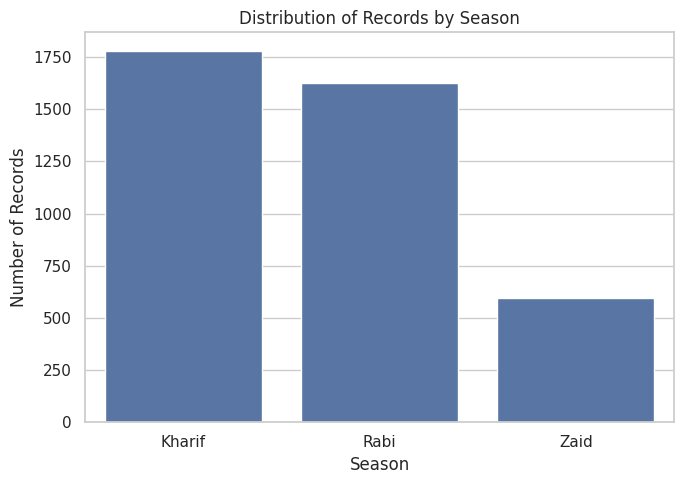

In [28]:
# Univariate: Season distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Season"
)

plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

The count plot shows the distribution of agricultural records across different seasons. It helps identify whether the dataset contains a balanced number of observations for each season or whether some seasons have more records than others.

2. Important Categorical Variable – Crop

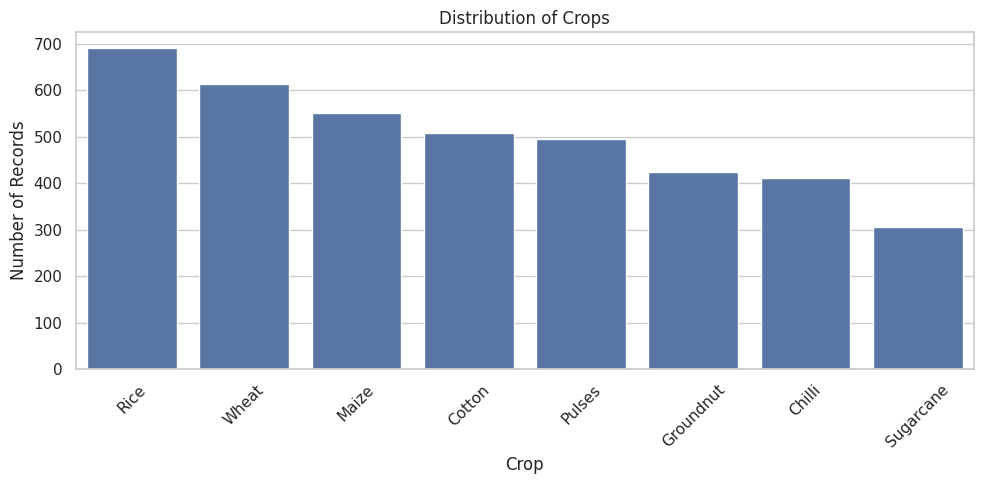

In [29]:
# Univariate: Crop distribution

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Crop",
    order=df["Crop"].value_counts().index
)

plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The crop distribution shows which crops have the highest and lowest number of records. This helps understand the representation of different crops in the dataset.

3. Important Numerical Variable – Rainfall

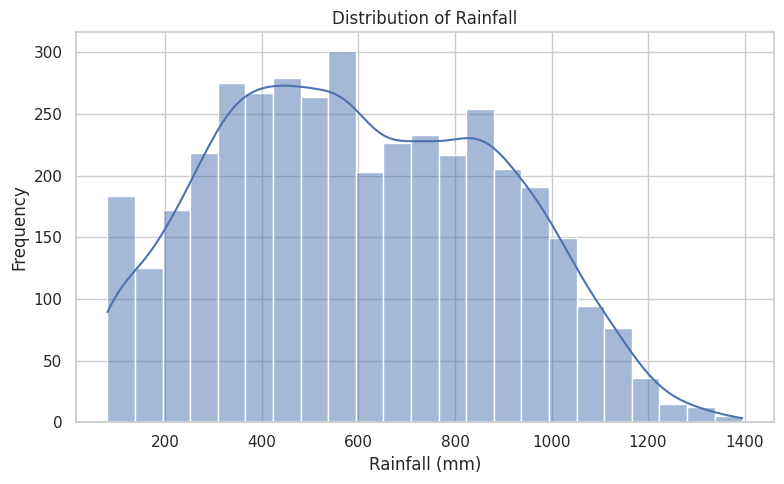

In [30]:
# Univariate: Rainfall distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Rainfall_mm",
    kde=True
)

plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

The rainfall distribution shows the range and frequency of rainfall values. It helps identify the typical rainfall conditions and possible extreme rainfall observations.

4. Production/Performance – Yield

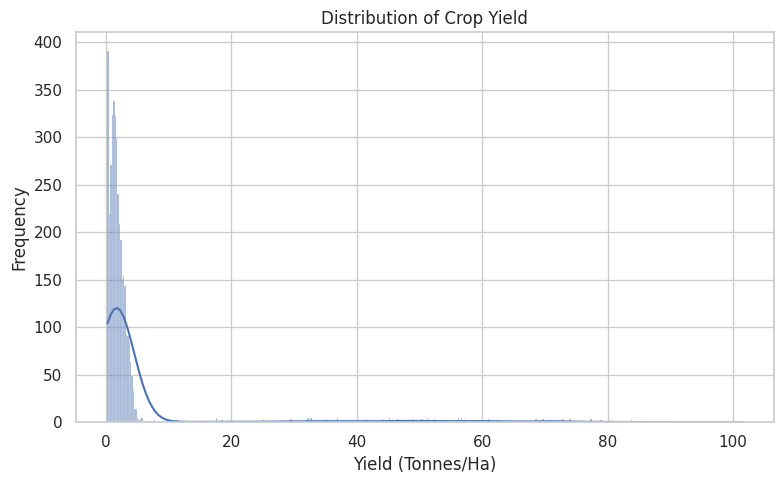

In [32]:
# Univariate: Yield distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Yield_Tonnes_Ha",
    kde=True
)

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

The yield distribution shows how crop productivity varies across farms. It helps identify the typical yield and unusually high or low yield observations.

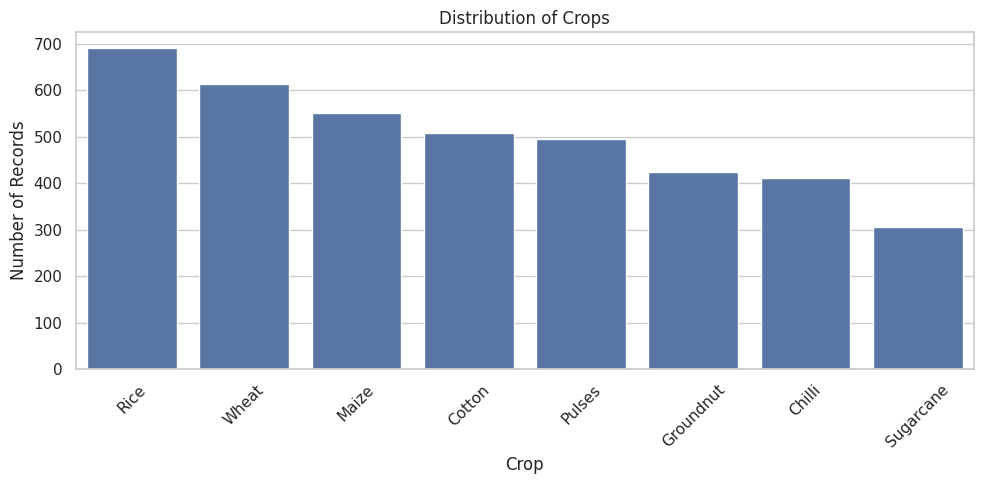

In [34]:
# Univariate: Crop distribution

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Crop",
    order=df["Crop"].value_counts().index
)

plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The count plot shows the distribution of different crops in the dataset. It helps identify which crops have the highest and lowest number of records and understand how well each crop is represented in the dataset.

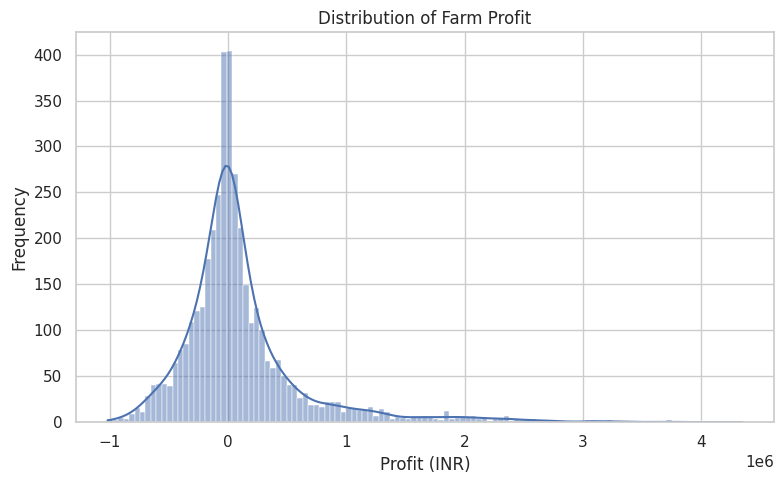

In [35]:
# Univariate: Profit distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Profit_INR",
    kde=True
)

plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

The profit distribution shows the variation in economic performance among farms. It helps identify farms with losses, typical profits, and unusually high profits.

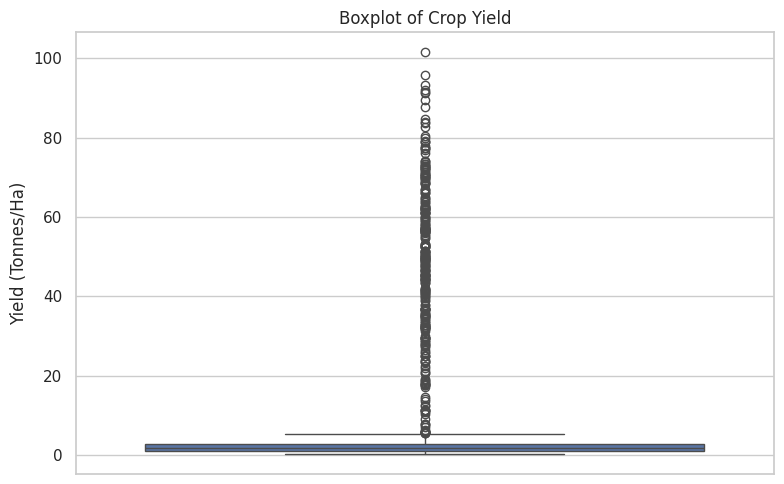

In [36]:
# Univariate: Yield boxplot

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    y="Yield_Tonnes_Ha"
)

plt.title("Boxplot of Crop Yield")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

The boxplot shows the distribution and variation of crop yield across the farms. It displays the median, spread of the yield values, and possible outliers. The outliers represent farms with unusually high or low yield values and should be investigated before deciding whether they are errors or legitimate observations.


**Univariate: Season Distribution — Pie Chart**

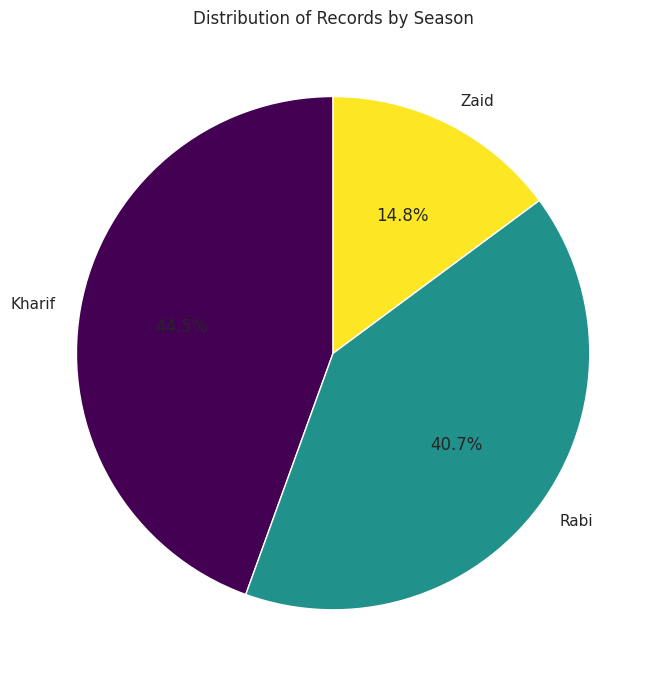

In [ ]:
# Univariate: Season distribution (Pie Chart)

plt.figure(figsize=(7, 7))

df["Season"].value_counts().plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    cmap="viridis"
)

plt.title("Distribution of Records by Season")
plt.ylabel("")

plt.tight_layout()
plt.show()

The pie chart shows the percentage distribution of agricultural records across different seasons. It helps compare the proportion of observations belonging to each season and understand whether the dataset has a balanced or uneven seasonal distribution.


# **Outliers investigated**

In [ ]:
# IQR-Based Outlier Summary

outlier_summary = []

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ][col]

    outlier_summary.append({
        "Variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outliers.count(),
        "Outlier_Percentage": (outliers.count() / df[col].count()) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,Farm_Area_Hectares,4.26,11.65,7.39,-6.83,22.73,0,0.00
1,Rainfall_mm,371.58,831.98,460.40,-319.02,1522.57,0,0.00
2,Avg_Temperature_C,23.90,29.60,5.70,15.35,38.15,2,0.05
3,Humidity_pct,54.77,71.90,17.13,29.09,97.59,6,0.15
4,Sunlight_Hours_Day,6.60,8.10,1.50,4.35,10.35,26,0.65
5,Soil_pH,6.26,7.14,0.88,4.94,8.46,0,0.00
6,Soil_Moisture_pct,21.80,31.20,9.40,7.70,45.30,5,0.12
7,Nitrogen_kg_ha,98.50,141.22,42.72,34.41,205.31,10,0.25
8,Phosphorus_kg_ha,46.20,69.40,23.20,11.40,104.20,16,0.40
9,Potassium_kg_ha,86.20,123.60,37.40,30.10,179.70,32,0.80


In [37]:
# Outlier Analysis using IQR

Q1 = df["Yield_Tonnes_Ha"].quantile(0.25)
Q3 = df["Yield_Tonnes_Ha"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Yield_Tonnes_Ha"] < lower_bound) |
    (df["Yield_Tonnes_Ha"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))

Q1: 1.05
Q3: 2.83
IQR: 1.78
Lower Bound: -1.6199999999999999
Upper Bound: 5.5
Number of Outliers: 302


In [39]:
# Display potential yield outliers

outliers[[
    "Farm_ID",
    "State",
    "District",
    "Crop",
    "Season",
    "Yield_Tonnes_Ha"
]].sort_values("Yield_Tonnes_Ha")

,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha
1906,SF11907,Maharashtra,Warangal,Maize,Kharif,5.59
1468,SF11469,Karnataka,Warangal,Maize,Kharif,5.66
1526,SF11527,Madhya Pradesh,Nalgonda,Rice,Kharif,5.67
1620,SF11621,Karnataka,Guntur,Maize,Kharif,5.70
2318,SF12319,Telangana,Indore,Rice,Kharif,5.70
...,...,...,...,...,...,...
3523,SF13524,Karnataka,Nashik,Sugarcane,Kharif,91.46
1464,SF11465,Gujarat,Nashik,Sugarcane,Kharif,91.98
3525,SF13526,Andhra Pradesh,Erode,Sugarcane,Rabi,93.13
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,95.79


Potential outliers in crop yield are identified using the Interquartile Range (IQR) method. Values below the lower bound or above the upper bound are treated as potential outliers. These observations are not automatically removed. They should be investigated to determine whether they are data-entry problems, legitimate observations, or values requiring further investigation.


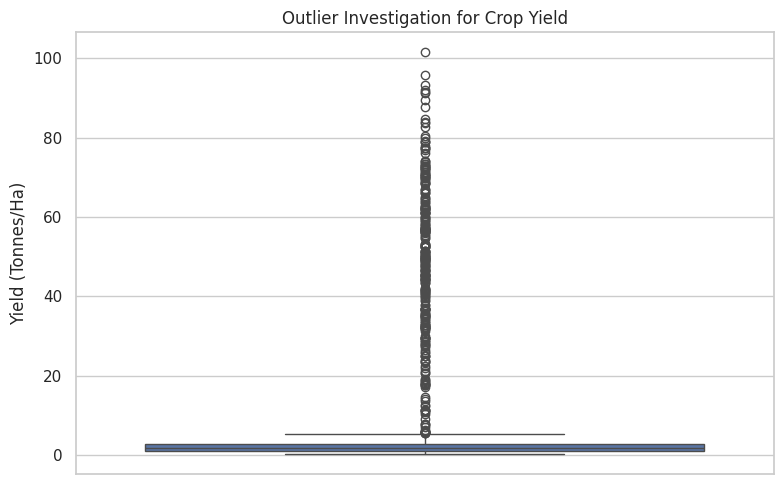

In [61]:
# Boxplot for Yield

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    y="Yield_Tonnes_Ha"
)

plt.title("Outlier Investigation for Crop Yield")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

Outliers were investigated using the IQR method and boxplots. Potential outliers were identified in the numerical variables. These observations were not automatically removed because they may represent genuine agricultural conditions or unusual farming situations. Further investigation is required before deciding whether they should be treated or retained.

## **Bivariate Analysis**

Bivariate analysis studies the relationship between two variables. For your agriculture dataset, the most useful relationships are between environmental/resource variables and agricultural performance.

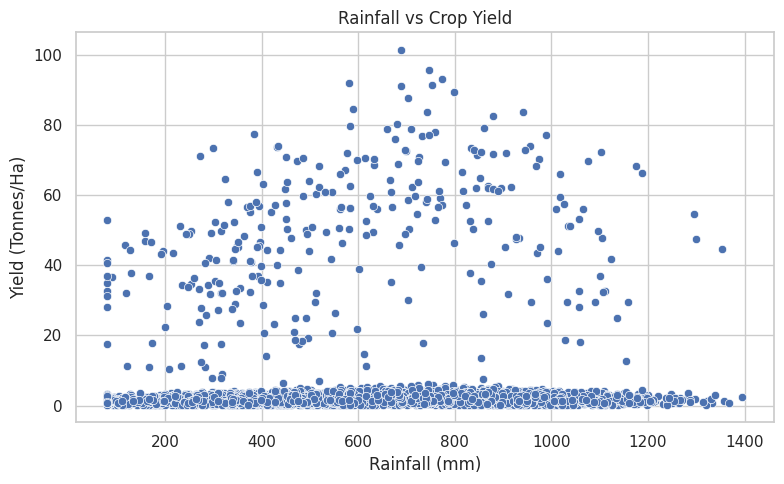

In [42]:
# Bivariate: Rainfall vs Yield

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha"
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

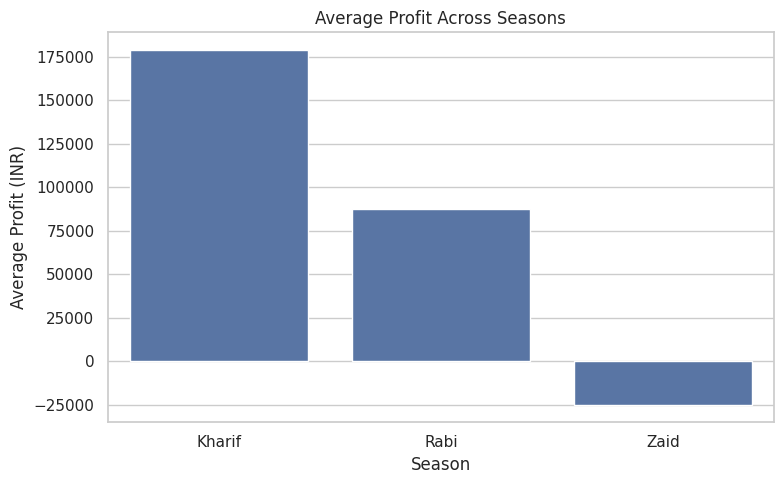

In [43]:
# Bivariate: Season vs Profit

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR",
    errorbar=None
)

plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.tight_layout()
plt.show()

The bar plot compares the average farm profit across different seasons. It helps identify which seasons have higher or lower average profitability and understand how seasonal conditions may influence the economic performance of farms.


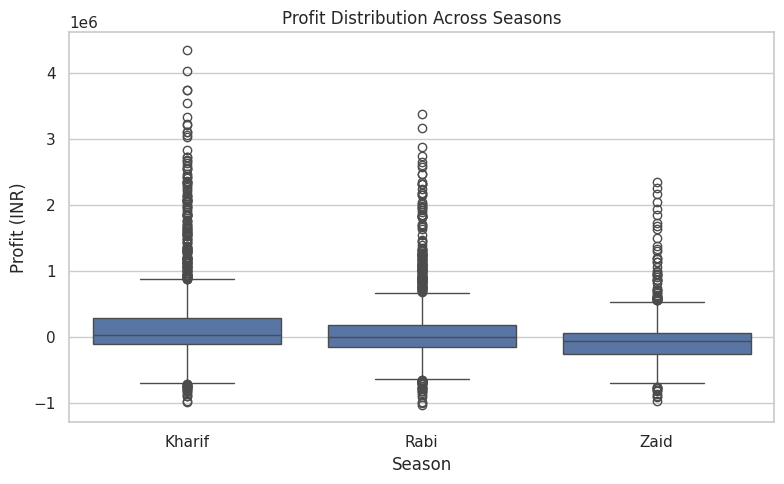

In [44]:
# Bivariate: Season vs Profit

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Profit_INR"
)

plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show()

The boxplot compares the distribution of farm profit across different seasons. It shows the median profit, variation, and potential outliers for each season. This helps identify which seasons generally have higher or lower profitability and whether some seasons contain unusually high or low profit values.


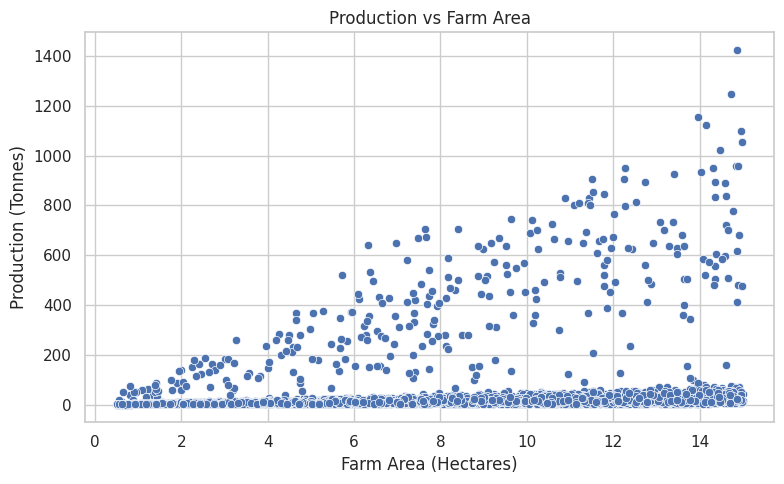

In [45]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Farm_Area_Hectares",
    y="Production_Tonnes"
)

plt.title("Production vs Farm Area")
plt.xlabel("Farm Area (Hectares)")
plt.ylabel("Production (Tonnes)")

plt.tight_layout()
plt.show()

The scatter plot shows the relationship between farm area and total production. It helps determine whether larger farm areas are generally associated with higher agricultural production and identify any unusual observations.

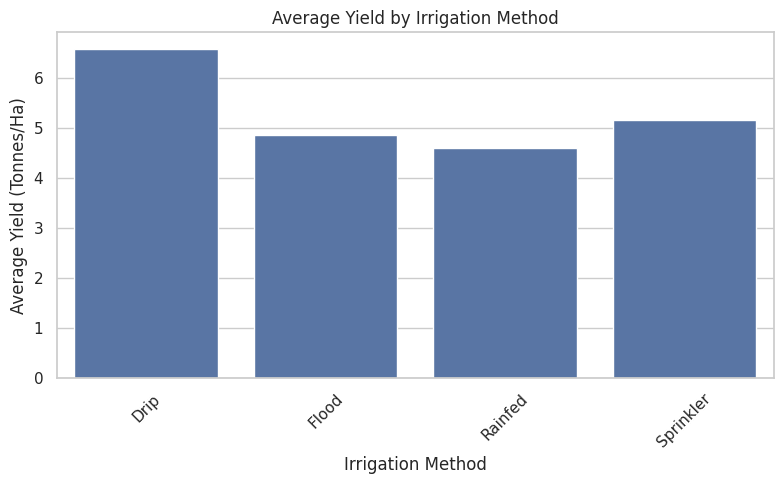

In [46]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    errorbar=None
)

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The bar plot compares the average crop yield across different irrigation methods. It helps identify which irrigation methods are associated with higher or lower average crop yield.

# **Multivariate Analysis**

Multivariate analysis means studying 3 or more variables together to understand how different factors are related to agricultural performance.

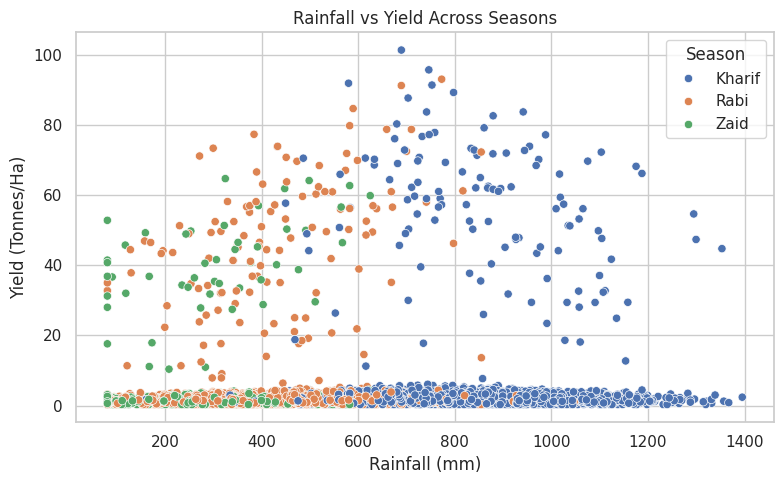

In [47]:
# Multivariate: Season, Rainfall and Yield

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Rainfall vs Yield Across Seasons")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

This plot studies rainfall and crop yield across different seasons. The different colors represent seasons and help identify whether the relationship between rainfall and yield changes from one season to another

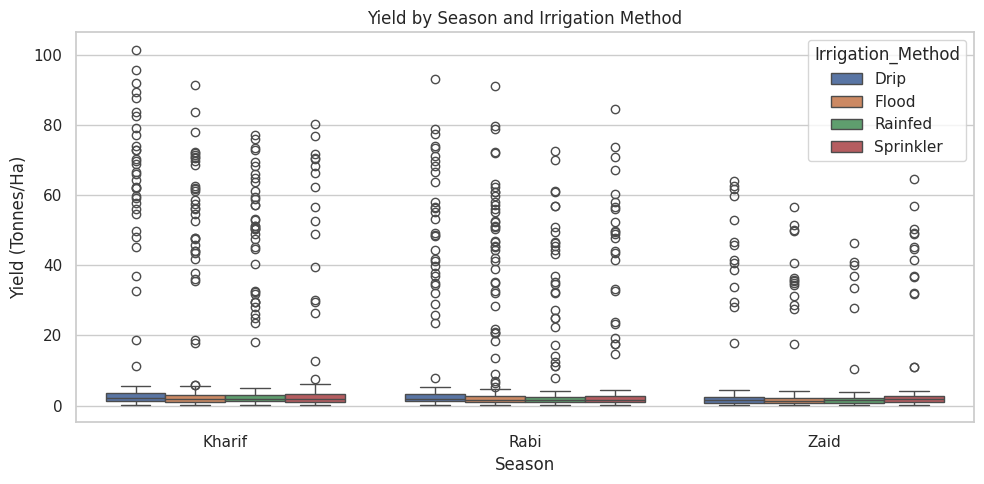

In [48]:
# Multivariate: Season, Irrigation Method and Yield

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    hue="Irrigation_Method"
)

plt.title("Yield by Season and Irrigation Method")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

This plot compares crop yield for different irrigation methods across seasons. It helps understand how irrigation methods and seasonal conditions together affect crop yield.

Multivariate Analysis: Pair Plot

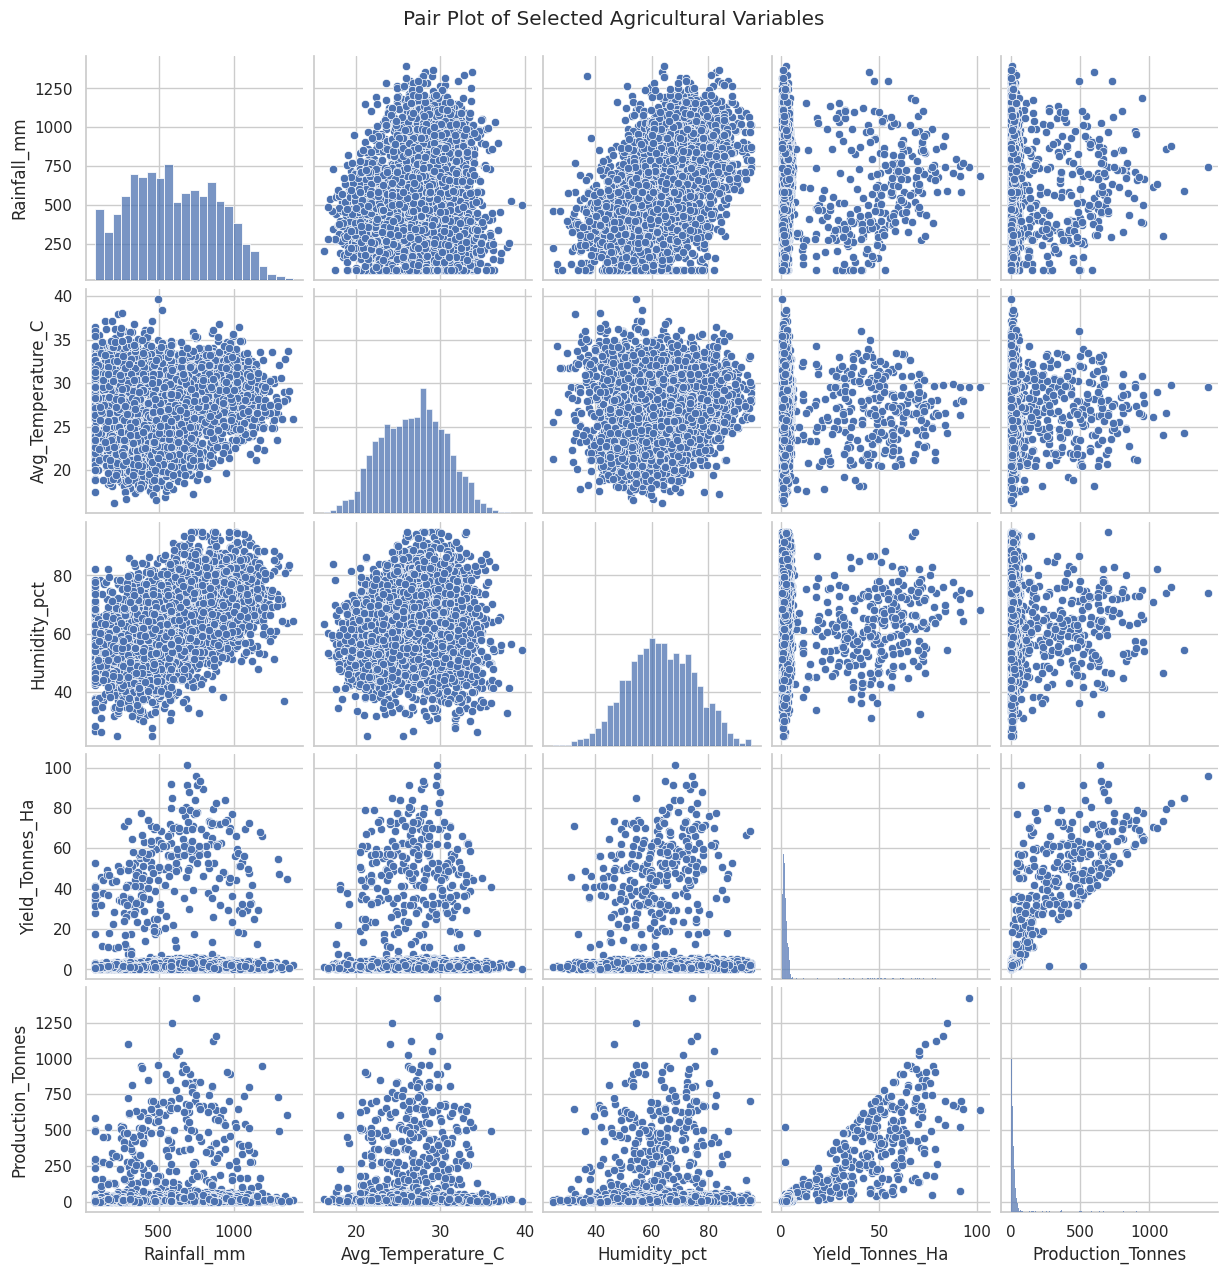

In [49]:
# Multivariate: Pair Plot

selected_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Yield_Tonnes_Ha",
    "Production_Tonnes"
]

sns.pairplot(
    df[selected_columns],
    diag_kind="hist"
)

plt.suptitle(
    "Pair Plot of Selected Agricultural Variables",
    y=1.02
)

plt.show()

The pair plot shows the relationships between selected environmental and agricultural performance variables. It helps identify patterns, correlations, and variations between rainfall, temperature, humidity, yield, and production. Coloring the observations by season helps compare these relationships across different seasons.

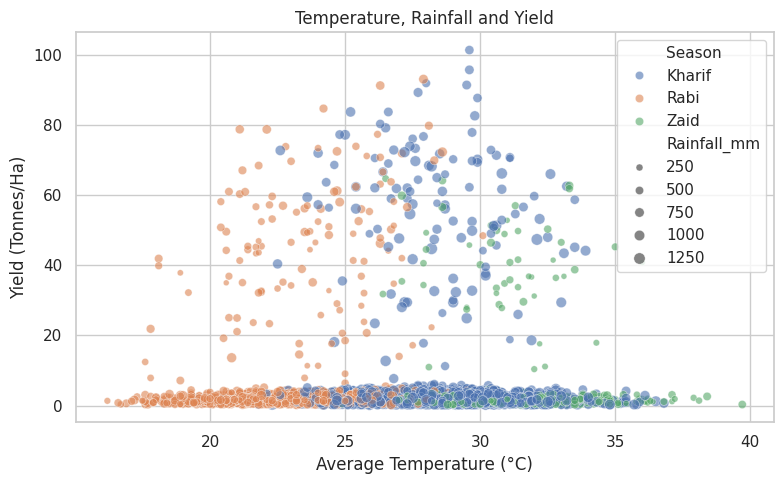

In [50]:
# Multivariate: Temperature, Rainfall and Yield

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha",
    size="Rainfall_mm",
    hue="Season",
    alpha=0.6
)

plt.title("Temperature, Rainfall and Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

This plot examines the combined effect of temperature, rainfall and season on crop yield. It helps identify whether yield changes under different environmental conditions.

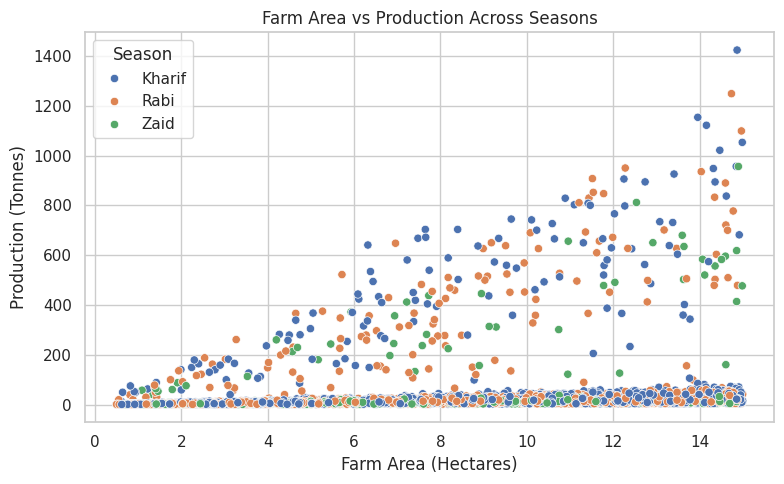

In [51]:
# Multivariate: Farm Area, Production and Season

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Farm_Area_Hectares",
    y="Production_Tonnes",
    hue="Season"
)

plt.title("Farm Area vs Production Across Seasons")
plt.xlabel("Farm Area (Hectares)")
plt.ylabel("Production (Tonnes)")

plt.tight_layout()
plt.show()

This plot examines the relationship between farm area and production across different seasons. It helps determine whether larger farms generally produce more and whether this relationship varies by season.

# **Correlation analysis**

**Correlation Heatmap**

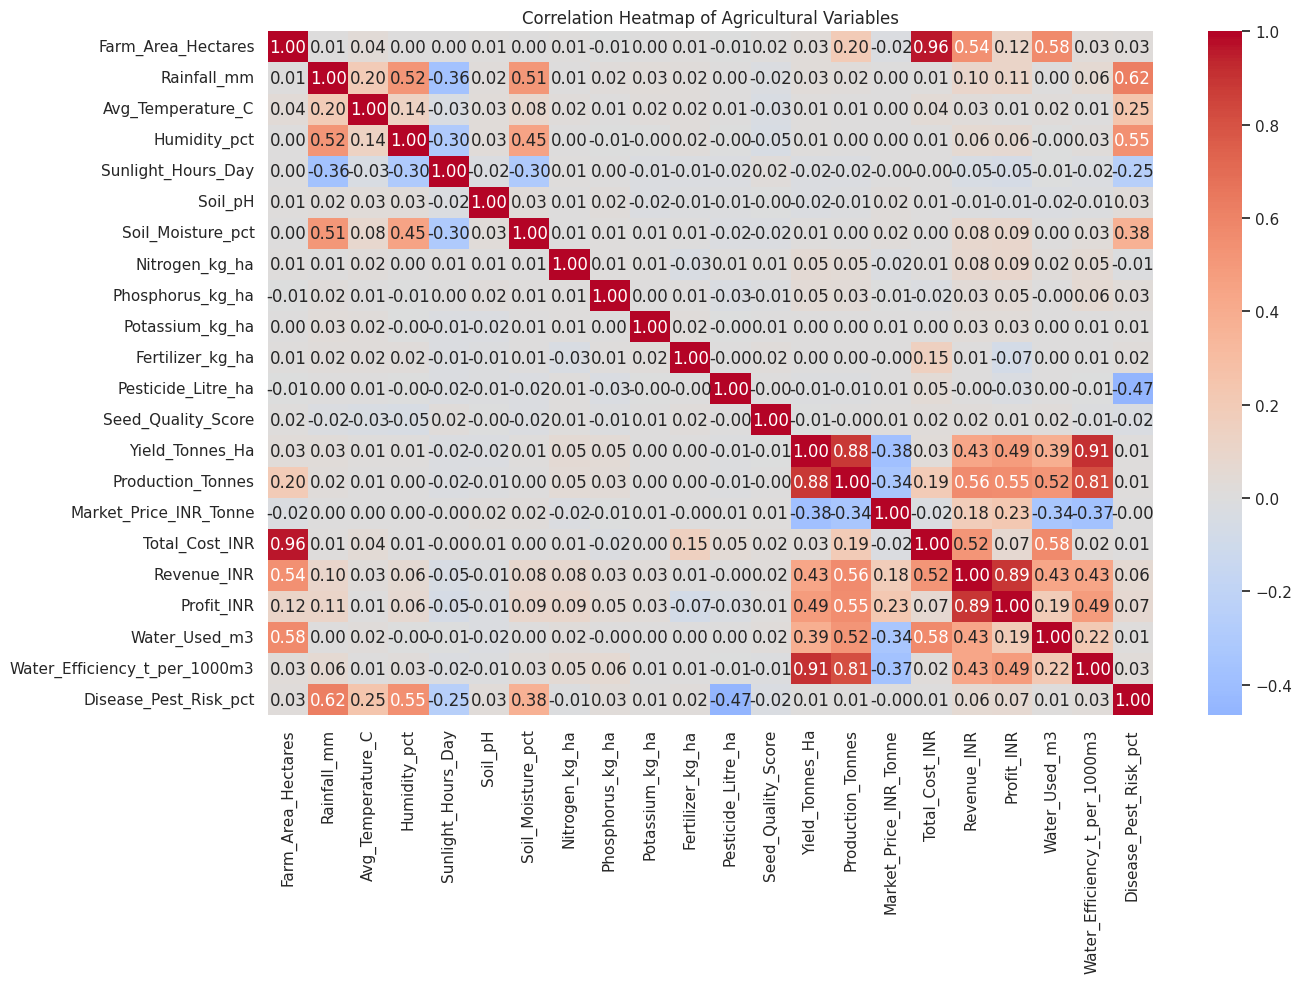

In [52]:
# Multivariate: Correlation Heatmap

numerical_columns = df.select_dtypes(include=np.number).columns

correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Agricultural Variables")

plt.tight_layout()
plt.show()

The correlation heatmap shows the relationships among multiple numerical variables at the same time. Positive values indicate that variables tend to increase together, while negative values indicate an inverse relationship. It helps identify important factors related to yield, production, water usage and profit.

In [60]:
# Correlation Analysis

numerical_columns = df.select_dtypes(include=np.number).columns

correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.00,0.01,0.04,0.00,0.00,0.01,0.00,0.01,-0.01,0.00,0.01,-0.01,0.02,0.03,0.20,-0.02,0.96,0.54,0.12,0.58,0.03,0.03
Rainfall_mm,0.01,1.00,0.20,0.52,-0.36,0.02,0.51,0.01,0.02,0.03,0.02,0.00,-0.02,0.03,0.02,0.00,0.01,0.10,0.11,0.00,0.06,0.62
Avg_Temperature_C,0.04,0.20,1.00,0.14,-0.03,0.03,0.08,0.02,0.01,0.02,0.02,0.01,-0.03,0.01,0.01,0.00,0.04,0.03,0.01,0.02,0.01,0.25
Humidity_pct,0.00,0.52,0.14,1.00,-0.30,0.03,0.45,0.00,-0.01,-0.00,0.02,-0.00,-0.05,0.01,0.00,0.00,0.01,0.06,0.06,-0.00,0.03,0.55
Sunlight_Hours_Day,0.00,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,-0.01,-0.02,0.02,-0.02,-0.02,-0.00,-0.00,-0.05,-0.05,-0.01,-0.02,-0.25
Soil_pH,0.01,0.02,0.03,0.03,-0.02,1.00,0.03,0.01,0.02,-0.02,-0.01,-0.01,-0.00,-0.02,-0.01,0.02,0.01,-0.01,-0.01,-0.02,-0.01,0.03
Soil_Moisture_pct,0.00,0.51,0.08,0.45,-0.30,0.03,1.00,0.01,0.01,0.01,0.01,-0.02,-0.02,0.01,0.00,0.02,0.00,0.08,0.09,0.00,0.03,0.38
Nitrogen_kg_ha,0.01,0.01,0.02,0.00,0.01,0.01,0.01,1.00,0.01,0.01,-0.03,0.01,0.01,0.05,0.05,-0.02,0.01,0.08,0.09,0.02,0.05,-0.01
Phosphorus_kg_ha,-0.01,0.02,0.01,-0.01,0.00,0.02,0.01,0.01,1.00,0.00,0.01,-0.03,-0.01,0.05,0.03,-0.01,-0.02,0.03,0.05,-0.00,0.06,0.03
Potassium_kg_ha,0.00,0.03,0.02,-0.00,-0.01,-0.02,0.01,0.01,0.00,1.00,0.02,-0.00,0.01,0.00,0.00,0.01,0.00,0.03,0.03,0.00,0.01,0.01


Correlation analysis is used to identify the relationships between numerical variables in the dataset. The correlation matrix shows the strength and direction of these relationships

# **Seasonal comparisons**

1. Average Yield Across Seasons

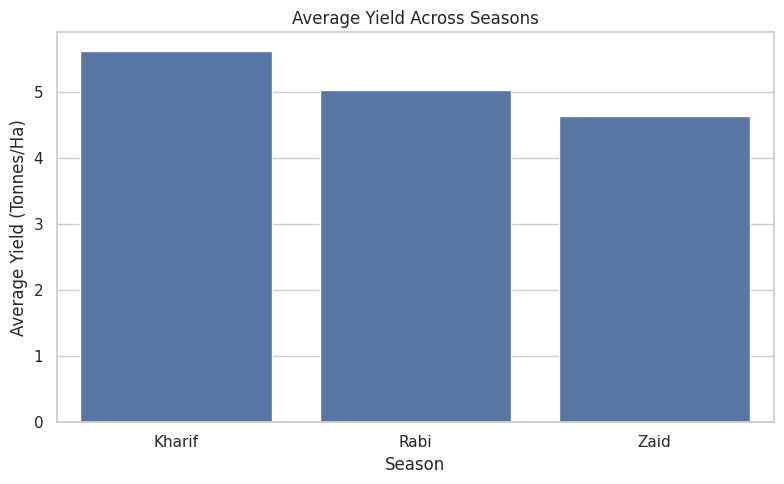

In [62]:
# Seasonal Comparison: Average Yield

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    errorbar=None
)

plt.title("Average Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

This bar plot compares the average crop yield across different seasons. It helps identify which seasons have higher or lower average crop yield.

2. Average Production Across Seasons


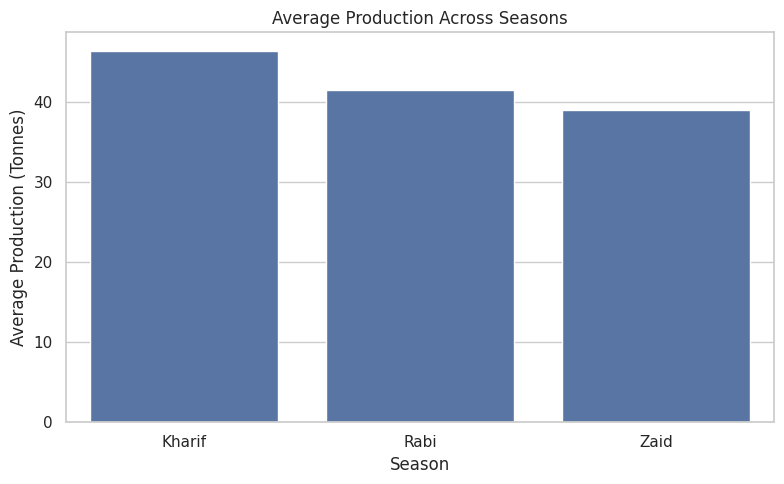

In [63]:
# Seasonal Comparison: Average Production

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Production_Tonnes",
    errorbar=None
)

plt.title("Average Production Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")

plt.tight_layout()
plt.show()

This bar plot compares the average agricultural production across different seasons. It helps identify differences in production between seasons.

3. Average Profit Across Seasons

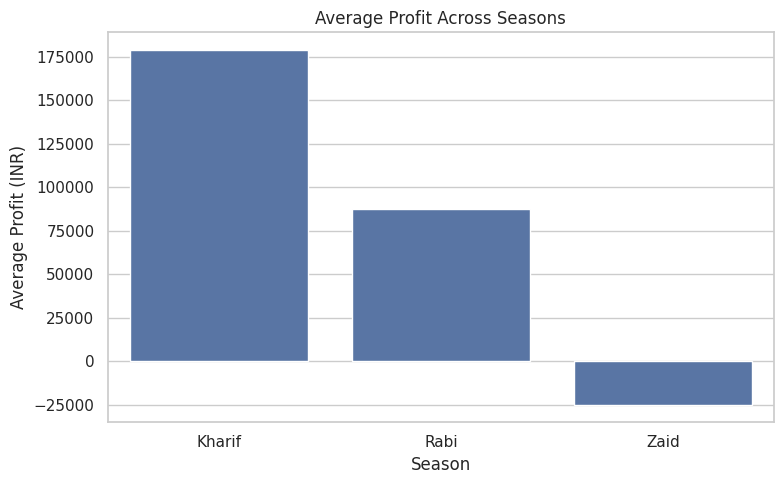

In [64]:
# Seasonal Comparison: Average Profit

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR",
    errorbar=None
)

plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.tight_layout()
plt.show()

This bar plot compares the average profit across different seasons. It helps identify which seasons show higher or lower average profitability.

4. Average Water Usage Across Seasons

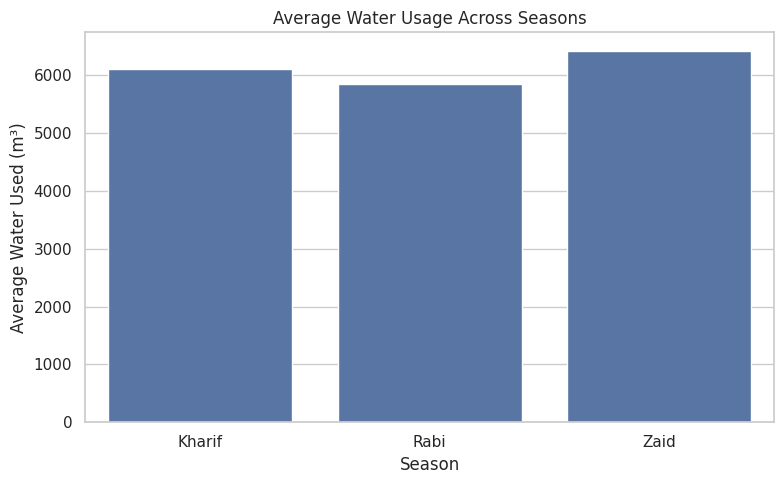

In [65]:
# Seasonal Comparison: Average Water Usage

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Water_Used_m3",
    errorbar=None
)

plt.title("Average Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Water Used (m³)")

plt.tight_layout()
plt.show()

This bar plot compares the average water usage across different seasons. It helps understand how water requirements vary between seasons.

# **Student-Designed Analyses**

Analysis 1 — Irrigation Method vs Yield

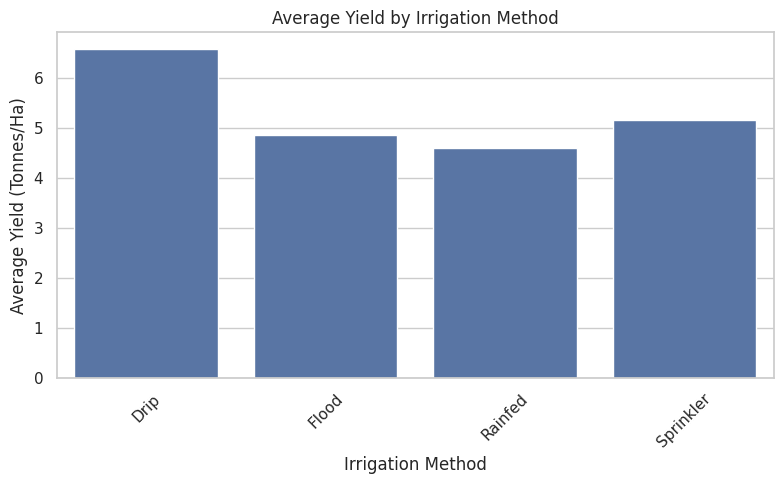

In [55]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    errorbar=None
)

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Different irrigation methods show differences in average crop yield, indicating that irrigation practices may influence agricultural performance.

Analysis 2 — Farm Area vs Production

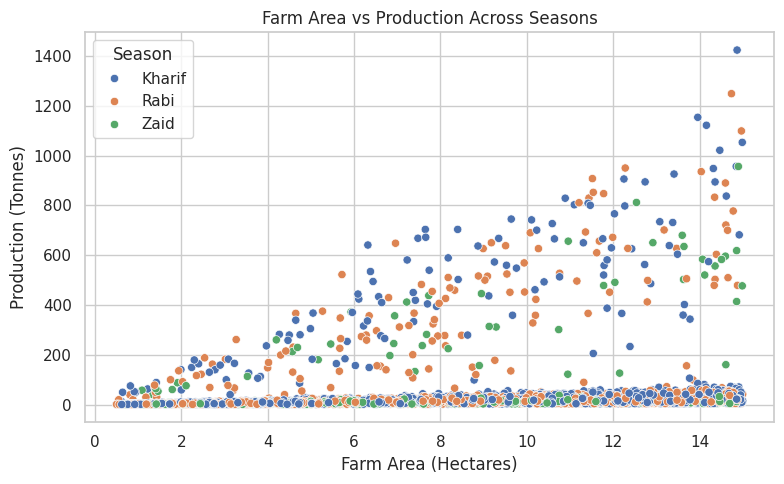

In [56]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Farm_Area_Hectares",
    y="Production_Tonnes",
    hue="Season"
)

plt.title("Farm Area vs Production Across Seasons")
plt.xlabel("Farm Area (Hectares)")
plt.ylabel("Production (Tonnes)")

plt.tight_layout()
plt.show()

The analysis helps examine whether larger farm areas are associated with higher production and whether this relationship varies across seasons.

Analysis 3 — Season vs Profit

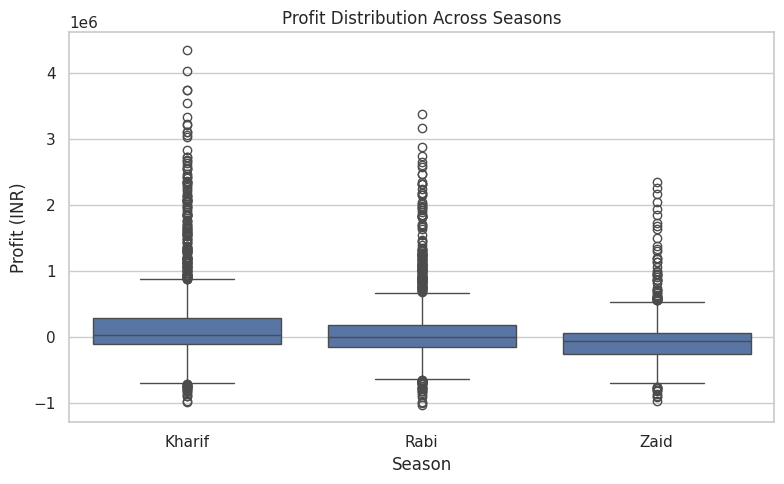

In [57]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Profit_INR"
)

plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show()

Profit varies across seasons, showing that seasonal conditions may influence the economic performance of farms.

**Meaningful Insights**

1. Seasonal performance varies: Different seasons show differences in agricultural performance, including yield, water usage and profit.

2. Rainfall and yield relationship: Rainfall conditions show a relationship with crop yield, and this relationship may vary across different seasons.

3. Farm area and production: Farm area shows a relationship with total production, with larger farms generally having higher production.

4. Irrigation method and yield: Average crop yield differs across irrigation methods, indicating an association between irrigation practices and crop productivity.

5. Profit varies across seasons: Profit levels differ across seasons, showing that seasonal conditions are associated with differences in economic performance.

6. Water usage varies: Average water usage differs across seasons, highlighting the importance of efficient water resource management.

7. Environmental conditions and performance: Variables such as temperature, rainfall and humidity show relationships with agricultural performance measures such as yield and production.

8. Extreme observations exist: Several numerical variables contain potential outliers. These observations should be investigated carefully before deciding whether they are errors or genuine agricultural conditions.

**Evidence-Based Recommendations**

1. Seasonal planning: Farmers should consider seasonal variations in rainfall, temperature and other environmental conditions when planning crop activities.

2. Efficient irrigation: Irrigation methods should be selected based on their observed yield performance and water requirements to improve water resource management.

3. Water management: Farmers should monitor water usage across seasons and adopt efficient water management practices where higher water consumption is observed.

4. Crop and season selection: Crops and farming activities can be planned by considering their observed performance across different seasons.

5. Yield improvement: Environmental conditions such as rainfall, temperature and humidity should be monitored because they show relationships with crop yield and production.

6. Farm resource management: Farm area, fertilizer, pesticide and other resource usage should be planned carefully to maintain productivity while controlling unnecessary costs.

7. Profit-focused planning: Farmers should consider both production and economic performance when making seasonal decisions, rather than focusing only on yield.

8. Outlier investigation: Unusual observations should be checked carefully to determine whether they represent data-entry issues or genuine agricultural conditions before making decisions based on them.

**Limitations**

1. The dataset contains some missing values, which may affect the analysis.

2. Some variables contain extreme values or outliers that may influence the results.

3. The dataset may not represent all regions, crops and farming conditions.

4. The analysis is based only on the variables available in the dataset.

5. The relationships found between variables do not always mean that one variable directly causes another.

6. More real-world information, such as detailed soil conditions, farming practices and long-term weather data, could improve the analysis.

## **Conclusion**

The analysis of the agricultural dataset shows that agricultural performance varies across different seasons. Differences were observed in crop yield, production, water usage, and profit across seasonal conditions.

The analysis also showed relationships between environmental factors such as rainfall, temperature and humidity and agricultural performance. Farm area was related to total production, while different irrigation methods showed differences in average crop yield.

The most useful findings are that seasonal conditions, resource usage and farming practices should be considered when evaluating agricultural performance. Water usage and profitability are also important factors along with crop yield and production.

The analysis has some limitations, including missing values, potential outliers, and limited information about real-world farming conditions. The relationships identified in the data should not always be considered as direct cause-and-effect relationships.

Overall, the findings can support better seasonal planning, efficient resource management, crop selection and future agricultural decision-making. Further analysis using larger datasets and additional environmental and farming information could provide deeper insights.